In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

from visions.backends.python.types import time

# from ydata_profiling import ProfileReport
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

df=pd.read_csv("C:/Users/yahia/PycharmProjects/JupyterProject3/data/HousingData.csv")
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  486.000000  486.000000  486.000000  486.000000  506.000000  506.000000   
mean     3.611874   11.211934   11.083992    0.069959    0.554695   

In [2]:
df.drop_duplicates(inplace=True)

In [3]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [4]:
print(df.to_string())
print(df.info())
print(df.describe())

         CRIM     ZN  INDUS  CHAS     NOX     RM    AGE      DIS  RAD  TAX  PTRATIO       B  LSTAT  MEDV
0     0.00632   18.0   2.31   0.0  0.5380  6.575   65.2   4.0900    1  296     15.3  396.90   4.98  24.0
1     0.02731    0.0   7.07   0.0  0.4690  6.421   78.9   4.9671    2  242     17.8  396.90   9.14  21.6
2     0.02729    0.0   7.07   0.0  0.4690  7.185   61.1   4.9671    2  242     17.8  392.83   4.03  34.7
3     0.03237    0.0   2.18   0.0  0.4580  6.998   45.8   6.0622    3  222     18.7  394.63   2.94  33.4
4     0.06905    0.0   2.18   0.0  0.4580  7.147   54.2   6.0622    3  222     18.7  396.90    NaN  36.2
5     0.02985    0.0   2.18   0.0  0.4580  6.430   58.7   6.0622    3  222     18.7  394.12   5.21  28.7
6     0.08829   12.5   7.87   NaN  0.5240  6.012   66.6   5.5605    5  311     15.2  395.60  12.43  22.9
7     0.14455   12.5   7.87   0.0  0.5240  6.172   96.1   5.9505    5  311     15.2  396.90  19.15  27.1
8     0.21124   12.5   7.87   0.0  0.5240  5.631  100.0

# Boston Housing Dataset - Attribute Information

The dataset contains the following attributes:

1. **CRIM** – Per capita crime rate by town.
2. **ZN** – Proportion of residential land zoned for lots over 25,000 sq. ft.
3. **INDUS** – Proportion of non-retail business acres per town.
4. **CHAS** – Charles River dummy variable (`1` if tract bounds river, `0` otherwise).
5. **NOX** – Nitric oxides concentration (parts per 10 million).
6. **RM** – Average number of rooms per dwelling.
7. **AGE** – Proportion of owner-occupied units built prior to 1940.
8. **DIS** – Weighted distances to five Boston employment centers.
9. **RAD** – Index of accessibility to radial highways.
10. **TAX** – Full-value property-tax rate per \$10,000.
11. **PTRATIO** – Pupil-teacher ratio by town.
12. **B** – `1000(Bk - 0.63)^2`, where `Bk` is the proportion of Black residents by town.
13. **LSTAT** – Percentage of lower-status population.
14. **MEDV** – Median value of owner-occupied homes (in \$1,000s).

<Axes: >

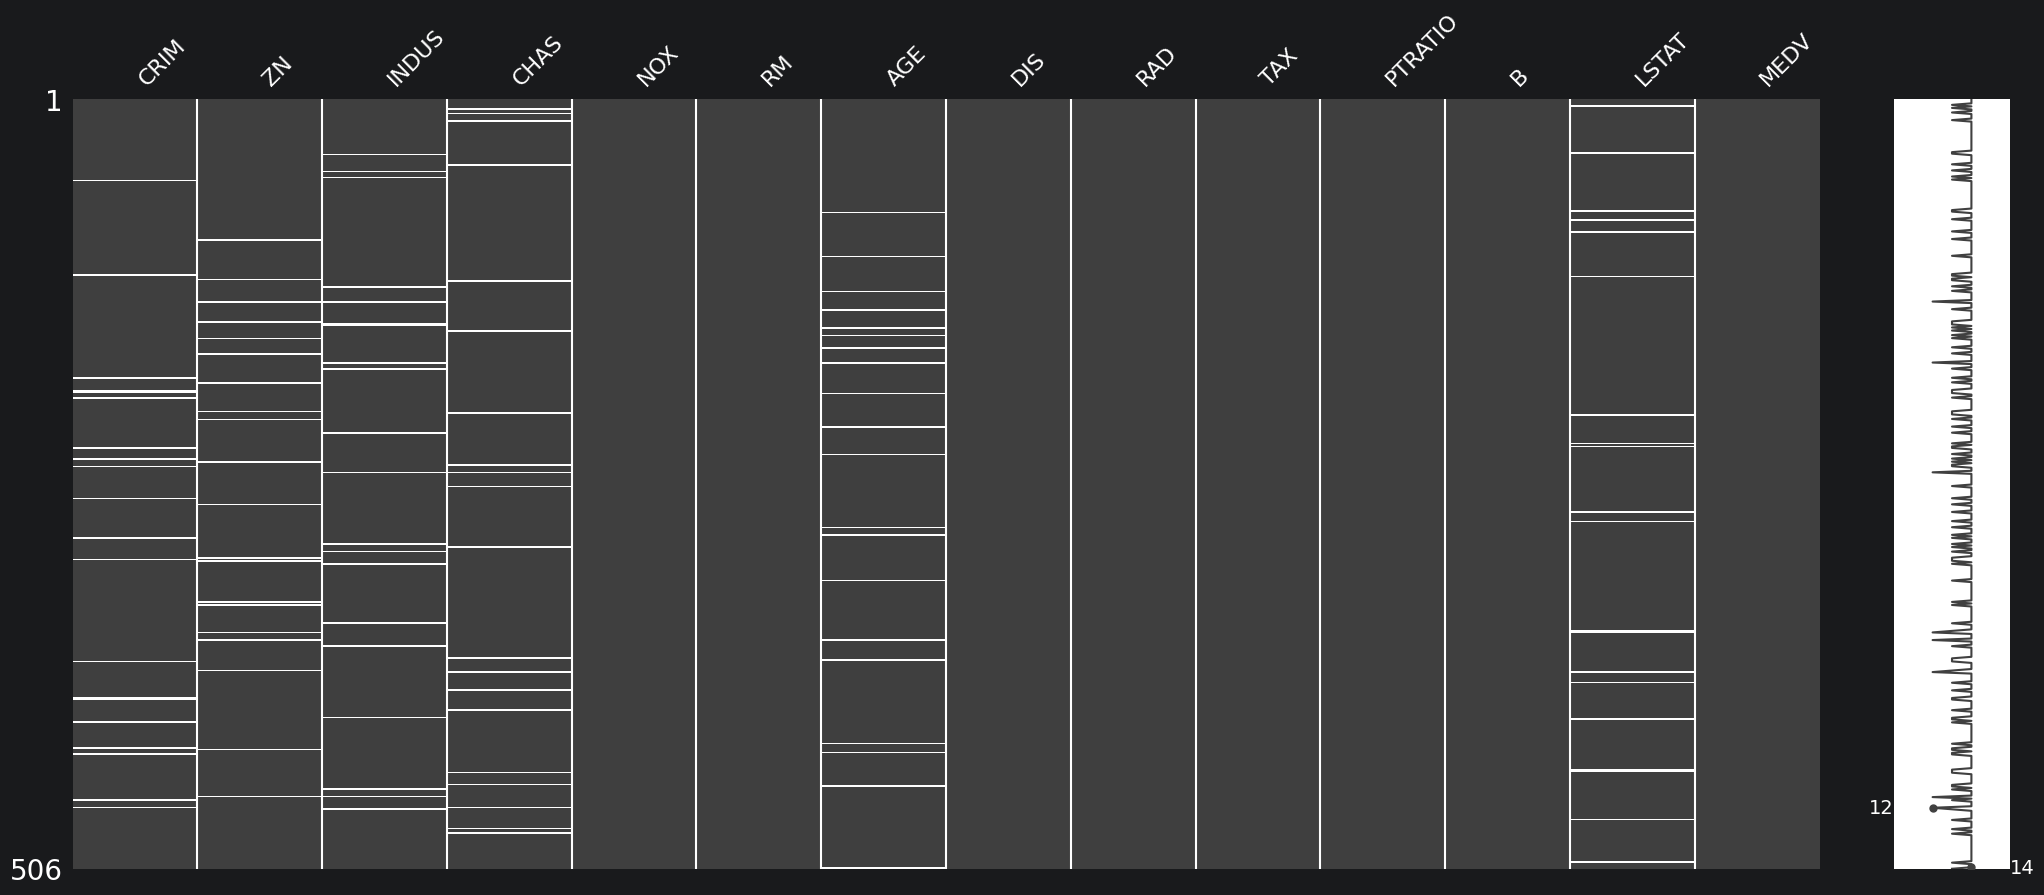

In [5]:
df.isnull().sum()
import missingno as msno
msno.matrix(df)  # or msno.heatmap(df) to see if missingness correlates across columns

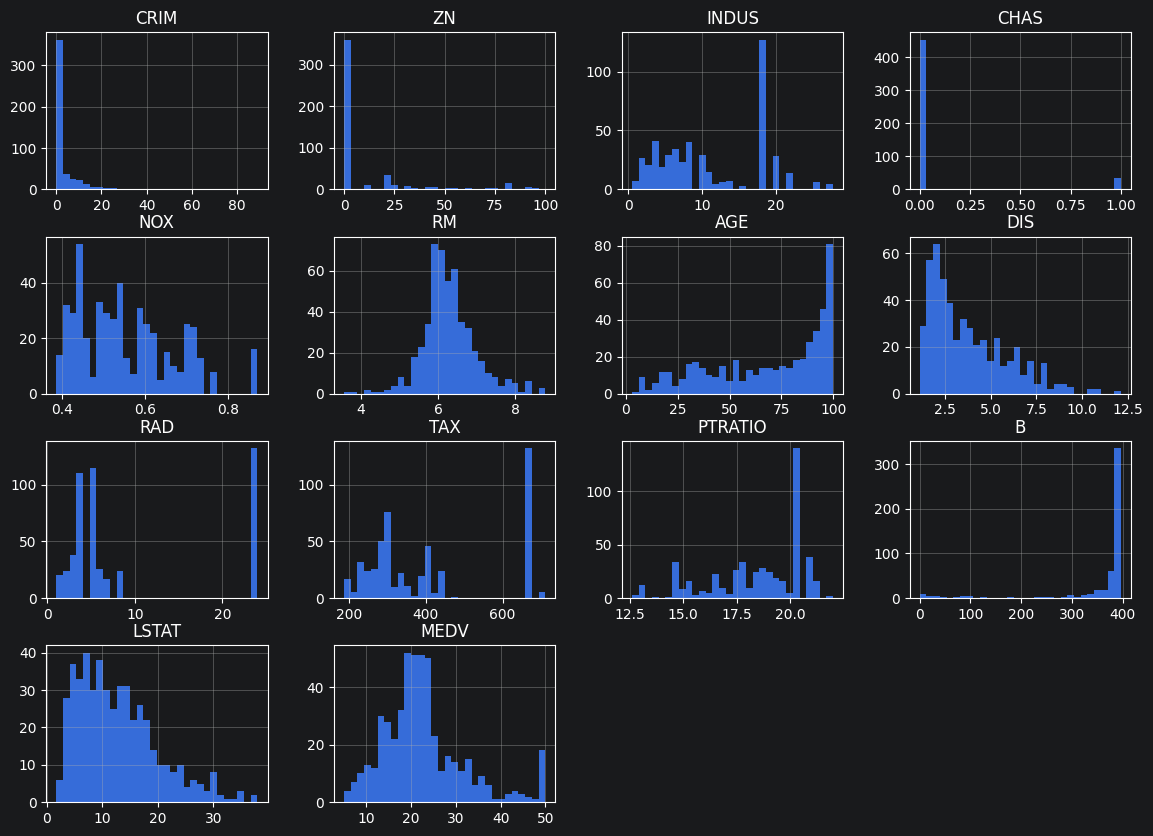

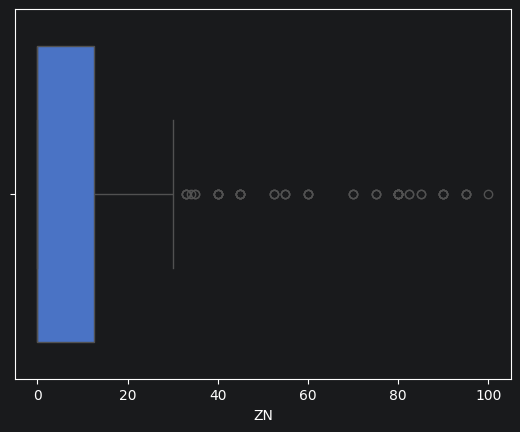

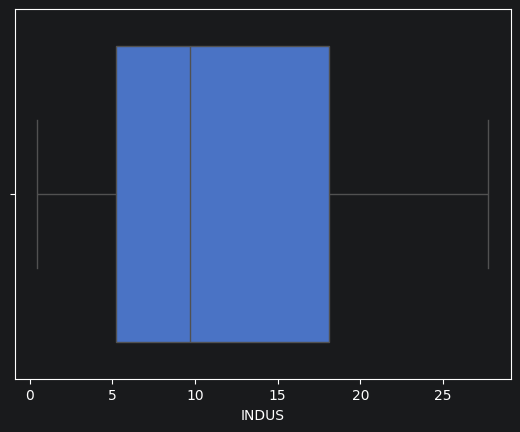

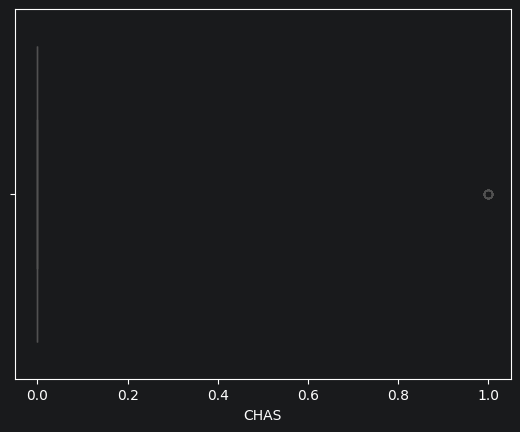

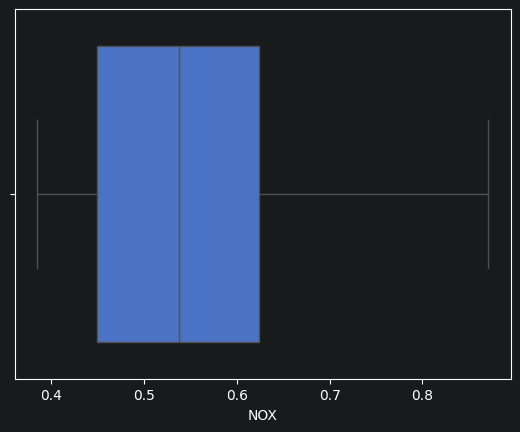

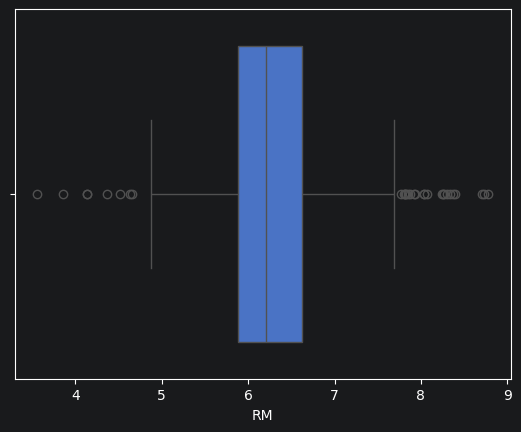

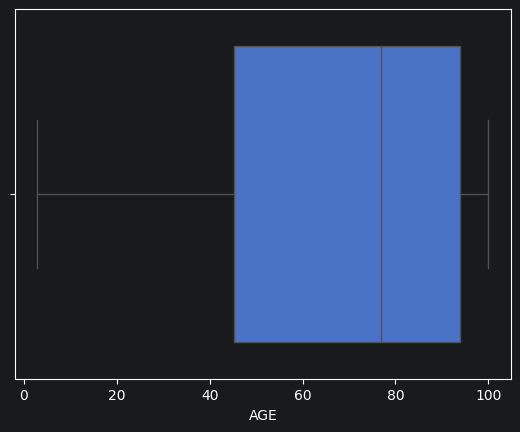

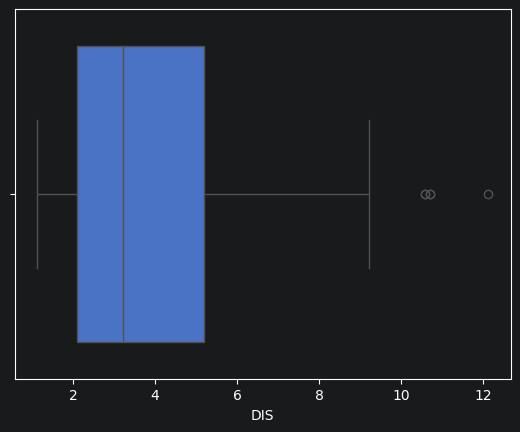

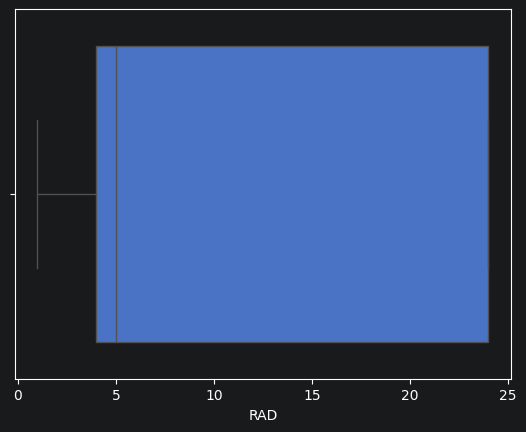

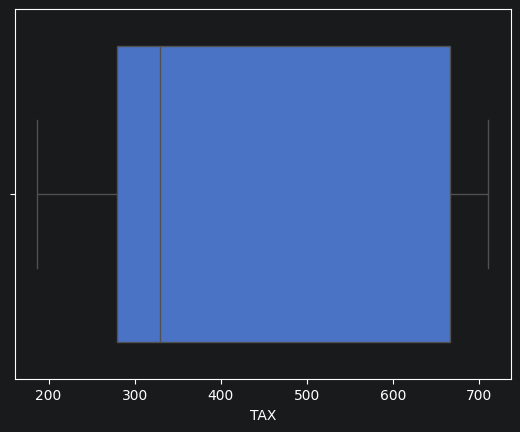

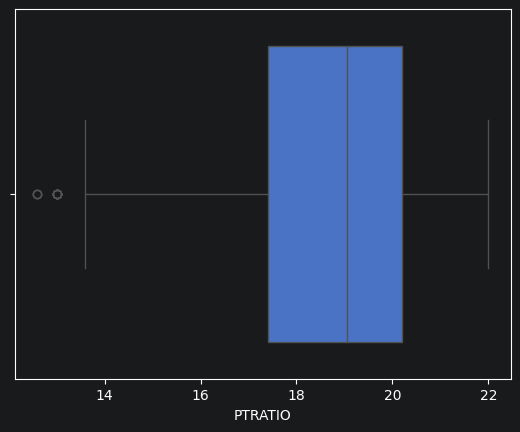

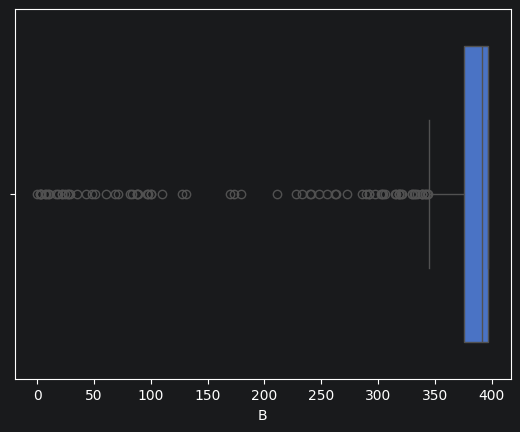

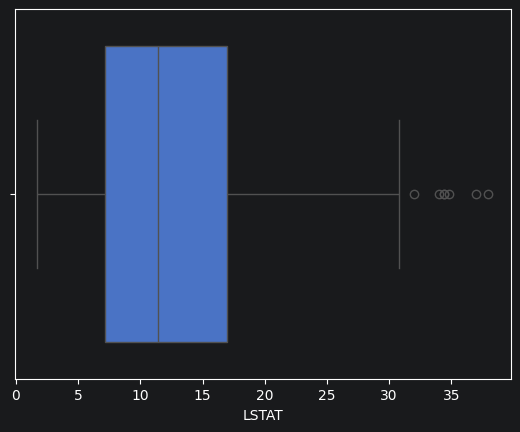

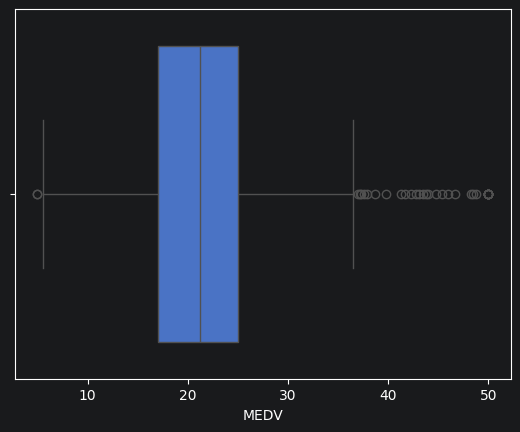

In [6]:
df.hist(figsize=(14,10), bins=30)
for col in df.columns:
    sns.boxplot(x=df[col]); plt.show()  # spot outliers/skew

In [7]:
print('Missing before:')
print(df.isnull().sum()[df.isnull().sum()>0])

for col in ['CRIM','ZN','LSTAT','AGE']:
    df[col] = df[col].fillna(df[col].median())

# mode for binary/categorical
df['CHAS'] = df['CHAS'].fillna(df['CHAS'].mode()[0])

# INDUS -- median too, it's multimodal
df['INDUS'] = df['INDUS'].fillna(df['INDUS'].median())

print()
print('Missing after:')
print(df.isnull().sum().sum())

Missing before:
CRIM     20
ZN       20
INDUS    20
CHAS     20
AGE      20
LSTAT    20
dtype: int64

Missing after:
0


In [8]:
df.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

In [9]:
df.head(100)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,11.43,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.12204,0.0,2.89,0.0,0.445,6.625,57.8,3.4952,2,276,18.0,357.98,6.65,28.4
96,0.11504,0.0,2.89,0.0,0.445,6.163,69.6,3.4952,2,276,18.0,391.83,11.34,21.4
97,0.12083,0.0,2.89,0.0,0.445,8.069,76.0,3.4952,2,276,18.0,396.90,4.21,38.7
98,0.08187,0.0,2.89,0.0,0.445,7.820,36.9,3.4952,2,276,18.0,393.53,3.57,43.8


In [10]:

# Log transform for heavily right-skewed CRIM (add small constant since some values near 0)
df['CRIM_log'] = np.log1p(df['CRIM'])

# Winsorize/cap B and RM at IQR bounds instead of deleting rows
def cap_iqr(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return s.clip(lower, upper)

df['B_capped'] = cap_iqr(df['B'])
df['RM_capped'] = cap_iqr(df['RM'])

print('CRIM skew before/after log:', df['CRIM'].skew(), '->', df['CRIM_log'].skew())
print('B outliers before/after cap:', (df['B'] < 344.11).sum(), '->', (df['B_capped'] < 344.11).sum())
print('RM outliers before/after cap:', ((df['RM']<4.78)|(df['RM']>7.73)).sum(), '->', ((df['RM_capped']<4.78)|(df['RM_capped']>7.73)).sum())


CRIM skew before/after log: 5.316108554141217 -> 1.3630981113986196
B outliers before/after cap: 77 -> 77
RM outliers before/after cap: 30 -> 30


In [11]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,CRIM_log,B_capped,RM_capped
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,0.006300,396.90,6.575
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0.026944,396.90,6.421
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,0.026924,392.83,7.185
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,0.031857,394.63,6.998
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,11.43,36.2,0.066770,396.90,7.147


In [12]:
print(df.head(200))

         CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  \
0    0.006320  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296   
1    0.027310   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242   
2    0.027290   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242   
3    0.032370   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222   
4    0.069050   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222   
..        ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
195  0.013810  80.0   0.46   0.0  0.422  7.875  32.0  5.6484    4  255   
196  0.253715  80.0   1.52   0.0  0.404  7.287  34.1  7.3090    2  329   
197  0.046660  80.0   1.52   0.0  0.404  7.107  36.6  7.3090    2  329   
198  0.037680  80.0   1.52   0.0  0.404  7.274  38.3  7.3090    2  329   
199  0.031500  95.0   1.47   0.0  0.403  6.975  15.3  7.6534    3  402   

     PTRATIO       B  LSTAT  MEDV  CRIM_log  B_capped  RM_capped  
0       15.3  396.90   4.98  24.0  0.006300 

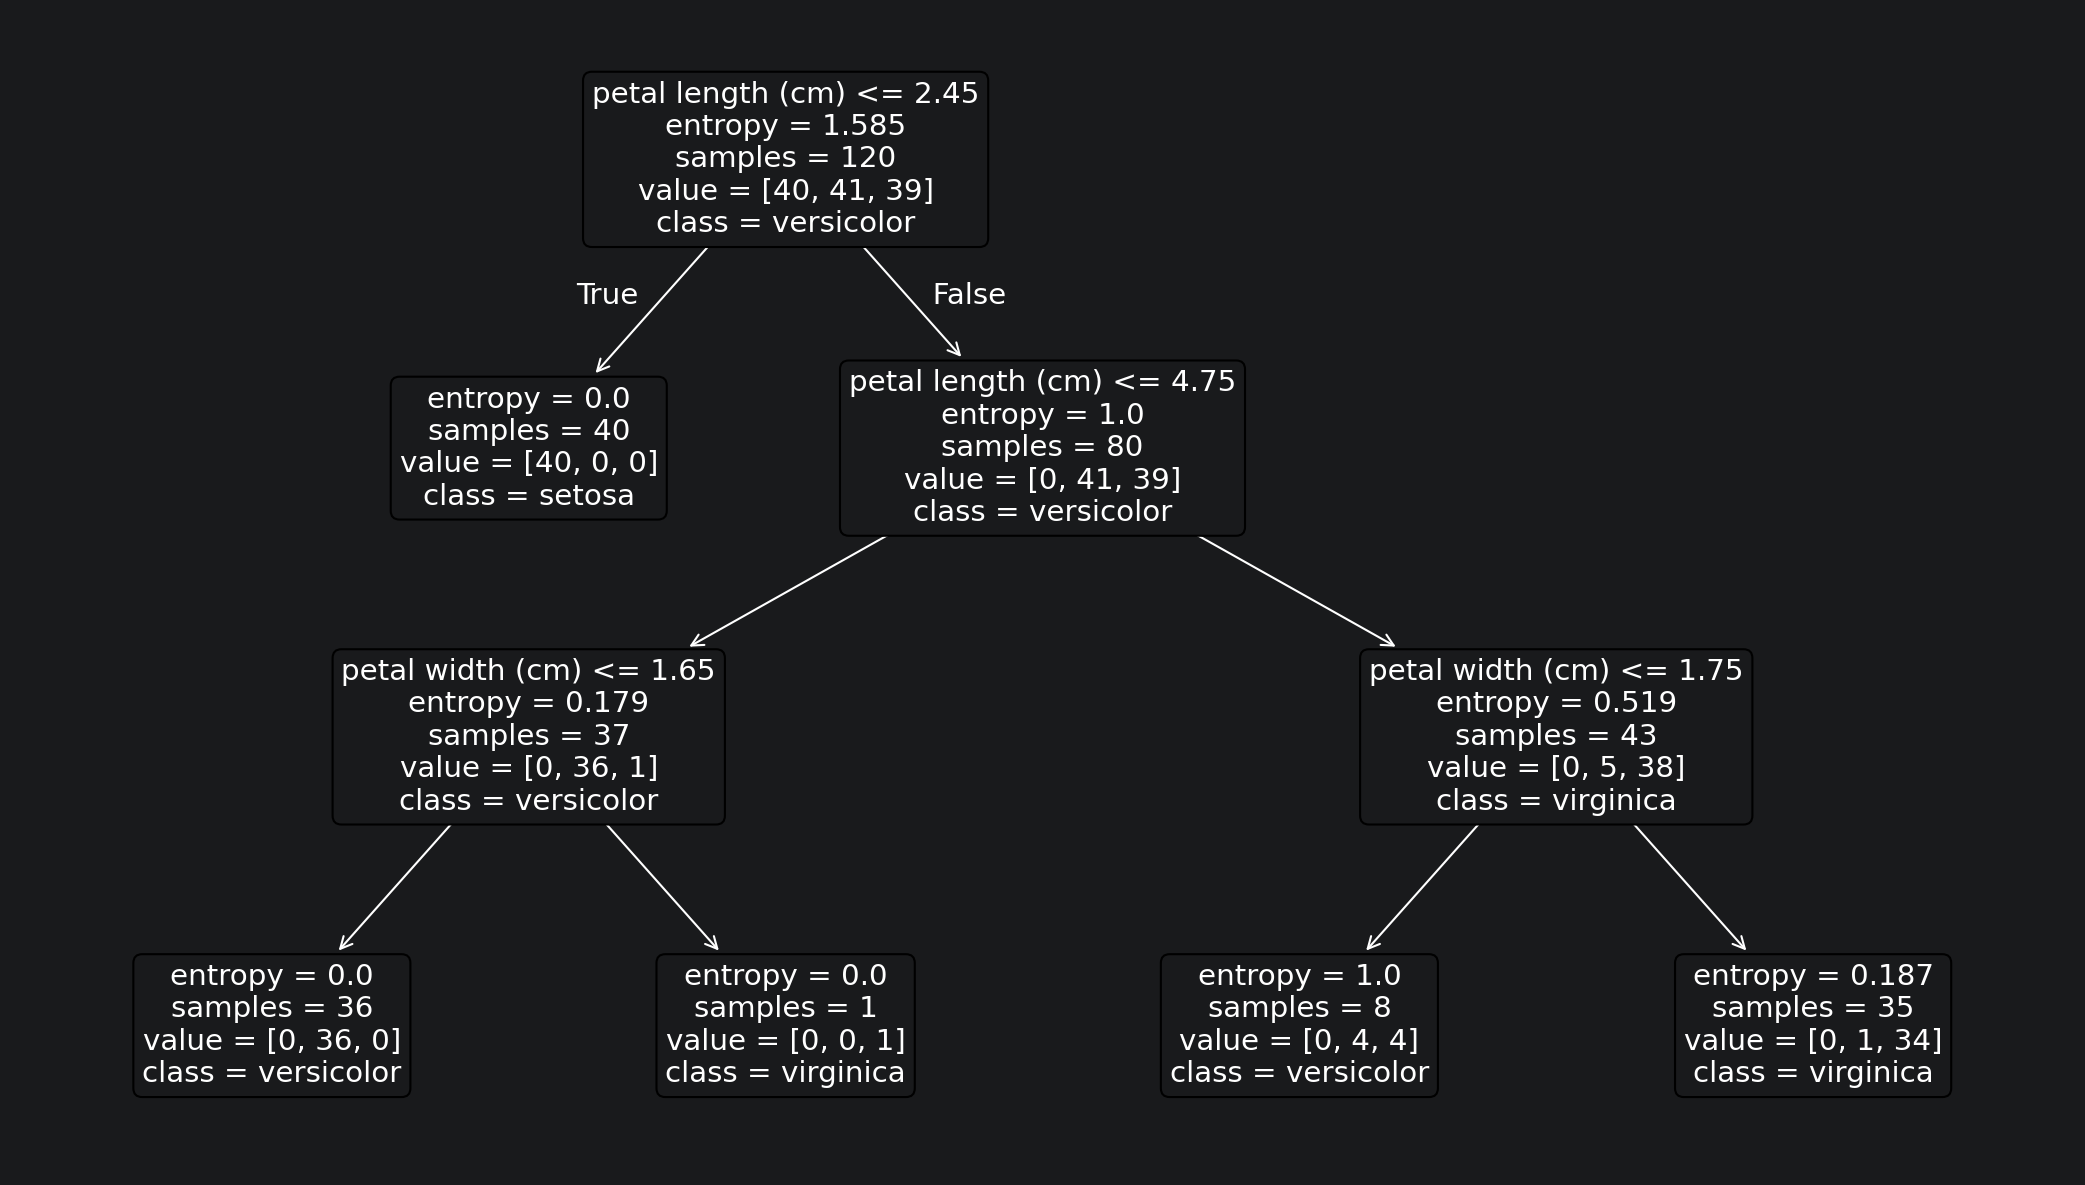

In [13]:
import matplotlib.pyplot as plt
import os
import datetime
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Load data and split
data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# 2. Build tree using Entropy
model = DecisionTreeClassifier(
    criterion="entropy", max_depth=3, random_state=42
)
model.fit(X_train, y_train)

# 3. Create the visual plot
plt.figure(figsize=(14, 8), dpi=150)
plot_tree(
    model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=False,       # Colors the nodes based on dominant class
    rounded=True,      # Rounds the corners of the node boxes
    impurity=True      # Explicitly shows the entropy value inside the box
)

# 4. Save and show
time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

plt.tight_layout()
plt.savefig(f"decision_tree_entropy_{time}.png")
plt.show()


In [14]:
print(df.to_string())

          CRIM     ZN  INDUS  CHAS     NOX     RM    AGE      DIS  RAD  TAX  PTRATIO       B  LSTAT  MEDV  CRIM_log   B_capped  RM_capped
0     0.006320   18.0   2.31   0.0  0.5380  6.575   65.2   4.0900    1  296     15.3  396.90   4.98  24.0  0.006300  396.90000     6.5750
1     0.027310    0.0   7.07   0.0  0.4690  6.421   78.9   4.9671    2  242     17.8  396.90   9.14  21.6  0.026944  396.90000     6.4210
2     0.027290    0.0   7.07   0.0  0.4690  7.185   61.1   4.9671    2  242     17.8  392.83   4.03  34.7  0.026924  392.83000     7.1850
3     0.032370    0.0   2.18   0.0  0.4580  6.998   45.8   6.0622    3  222     18.7  394.63   2.94  33.4  0.031857  394.63000     6.9980
4     0.069050    0.0   2.18   0.0  0.4580  7.147   54.2   6.0622    3  222     18.7  396.90  11.43  36.2  0.066770  396.90000     7.1470
5     0.029850    0.0   2.18   0.0  0.4580  6.430   58.7   6.0622    3  222     18.7  394.12   5.21  28.7  0.029413  394.12000     6.4300
6     0.088290   12.5   7.87   0.0

In [15]:
df_clean = df.drop(columns=['CRIM', 'B', 'RM'])

print(df_clean.isnull().sum())


ZN           0
INDUS        0
CHAS         0
NOX          0
AGE          0
DIS          0
RAD          0
TAX          0
PTRATIO      0
LSTAT        0
MEDV         0
CRIM_log     0
B_capped     0
RM_capped    0
dtype: int64


In [16]:
X = df_clean.drop(columns=['MEDV'])
y = df_clean['MEDV']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training shapes: {X_train.shape}, Testing shapes: {X_test.shape}")


Training shapes: (404, 13), Testing shapes: (102, 13)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Fit only on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


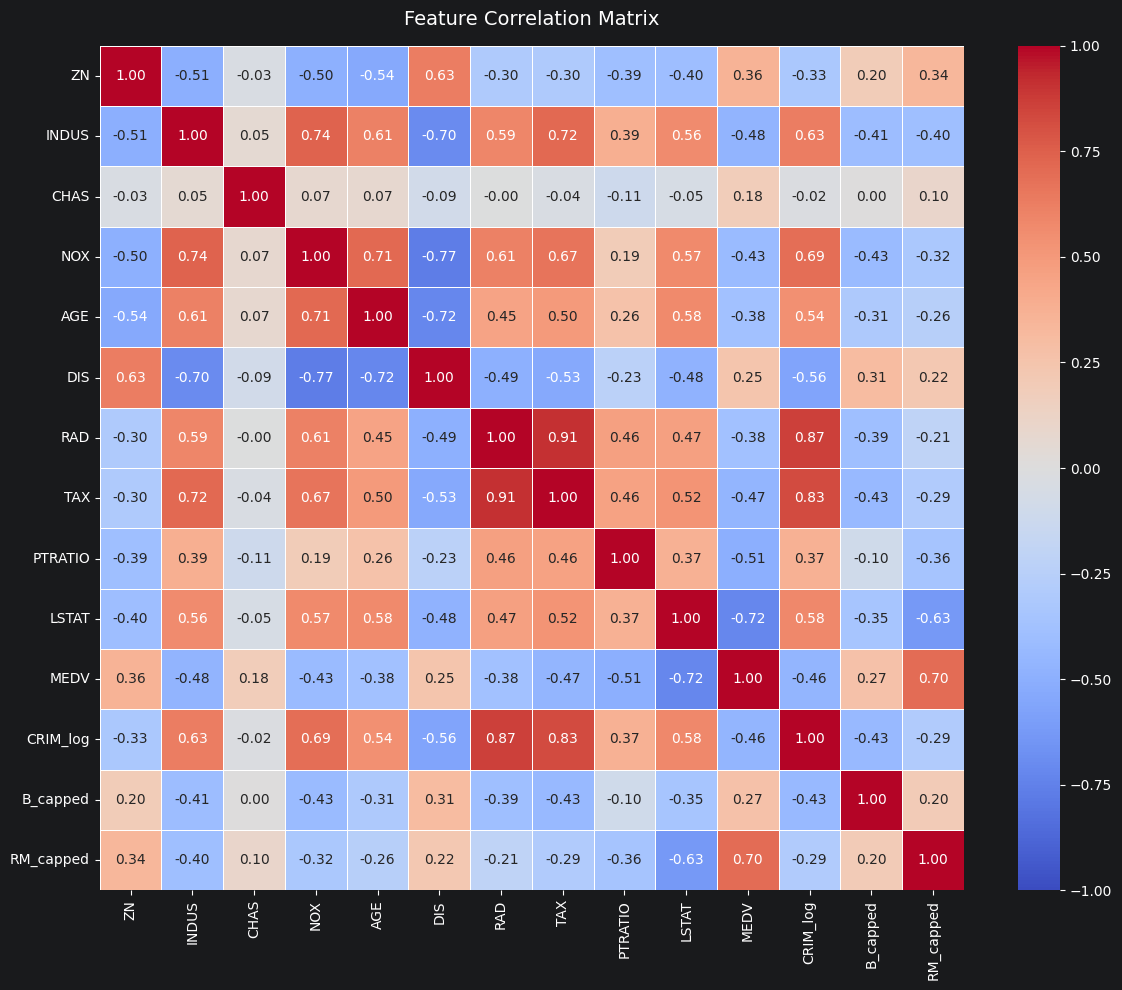

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix first
# Use df_clean if you already dropped the un-transformed columns
corr_matrix = df_clean.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Pass the corr_matrix (not df) into the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,         # Changed to True to read the exact correlation numbers
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1     # Standardizes the color bar from -1 to 1
)

plt.title("Feature Correlation Matrix", fontsize=14, pad=15)
plt.tight_layout()
plt.show()
